# `Projet Time Series Auto Hall` 

## `dataset`

- Les données boursières d’Auto Hall, issues de Casabourse, représentent les cotations journalières du titre à la Bourse de Casablanca, organisées sous forme de série temporelle.

- ### ***💰 Données de prix***

Prix d’ouverture (Open) : prix au début de la séance

Prix de clôture (Close / Price) : dernier prix de la séance

Prix le plus haut (High) : maximum atteint durant la séance

Prix le plus bas (Low) : minimum atteint durant la séance

### ***🏢 Informations sur l’entreprise***

Nom de la société : Auto Hall

Secteur d’activité : Distribution automobile

Marché : Bourse de Casablanca

### **📌 📅 Année de création de la société***

Auto Hall a été créée en 1907 et fait partie des premières entreprises du secteur automobile au Maroc.

### *LIEN*: https://www.investing.com/equities/auto-hall-historical-data

In [1]:
import numpy as np
from math import sqrt  # Racine carrée
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('/kaggle/input/auto-hall/Auto Hall.csv')
df

,Date,Price,Open,High,Low,Vol.,Change %
0,12/09/2025,93.00,93.98,93.98,93.00,0.14K,-1.04%
1,12/08/2025,93.98,94.00,94.00,91.36,0.13K,-0.01%
2,12/05/2025,93.99,91.02,94.00,91.02,3.44K,-0.37%
3,12/04/2025,94.34,92.10,94.38,91.00,7.51K,0.37%
4,12/03/2025,93.99,92.52,94.94,92.50,1.93K,-1.00%
...,...,...,...,...,...,...,...
4773,01/12/2000,22.25,22.25,22.25,22.25,0.22K,5.95%
4774,01/07/2000,21.00,21.00,21.00,21.00,0.08K,5.63%
4775,01/06/2000,19.88,19.88,19.88,19.88,0.10K,6.03%
4776,12/30/1999,18.75,18.75,18.75,18.75,0.02K,5.93%


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4778 entries, 0 to 4777
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Date      4778 non-null   object 
 1   Price     4778 non-null   float64
 2   Open      4778 non-null   float64
 3   High      4778 non-null   float64
 4   Low       4778 non-null   float64
 5   Vol.      4778 non-null   object 
 6   Change %  4778 non-null   object 
dtypes: float64(4), object(3)
memory usage: 261.4+ KB


# `Cleaning base`

In [3]:
df.isnull().sum()

Date        0
Price       0
Open        0
High        0
Low         0
Vol.        0
Change %    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.columns = df.columns.str.strip()
df = df.drop(columns=['Open', 'High', 'Low', 'Vol.', 'Change %'])

In [6]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=False)
df.set_index("Date", inplace=True)
df = df.sort_index()
df

,Price
Date,
1999-12-29,17.70
1999-12-30,18.75
2000-01-06,19.88
2000-01-07,21.00
2000-01-12,22.25
...,...
2025-12-03,93.99
2025-12-04,94.34
2025-12-05,93.99


In [7]:
import plotly.express as px

fig = px.line(df, x=df.index, y='Price', 
              title='Série Temporelle',
              labels={'Price': 'Prix', 'index': 'Date'},
              line_shape='linear')  # forme de ligne

# Modifier la couleur de la ligne en rouge
fig.update_traces(line=dict(color='red'))

# Ajouter une grille et taille
fig.update_layout(xaxis=dict(showgrid=True),
                  yaxis=dict(showgrid=True),
                  width=1000, height=500)

fig.show()

### `Statistiques Descriptives de Base`

In [8]:
df.describe()

,Price
count,4778.000000
mean,76.686457
std,29.701934
min,9.250000
25%,66.472500
50%,79.500000
75%,93.990000
max,167.900000


In [9]:
# Dates min et max
print("Date minimum :", df.index.min())
print("Date maximum :", df.index.max())

# Prix minimum et son jour
print("Jour du prix minimum :", df['Price'].idxmin())
print("Prix minimum :", df['Price'].min())

# Prix maximum et son jour
print("Jour du prix maximum :", df['Price'].idxmax())
print("Prix maximum :", df['Price'].max())

Date minimum : 1999-12-29 00:00:00
Date maximum : 2025-12-09 00:00:00
Jour du prix minimum : 2002-08-07 00:00:00
Prix minimum : 9.25
Jour du prix maximum : 2008-06-04 00:00:00
Prix maximum : 167.9


### `Identification des Composants`

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Décomposer la série temporelle
decomposition = seasonal_decompose(df['Price'], model='additive', period=7)

# Extraire les composants
tendance_decompose = decomposition.trend  # tendence
saisonnalite_decompose = decomposition.seasonal  # saisonnier
residus = decomposition.resid  # bruit

/tmp/ipykernel_17/1272887412.py:27: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.



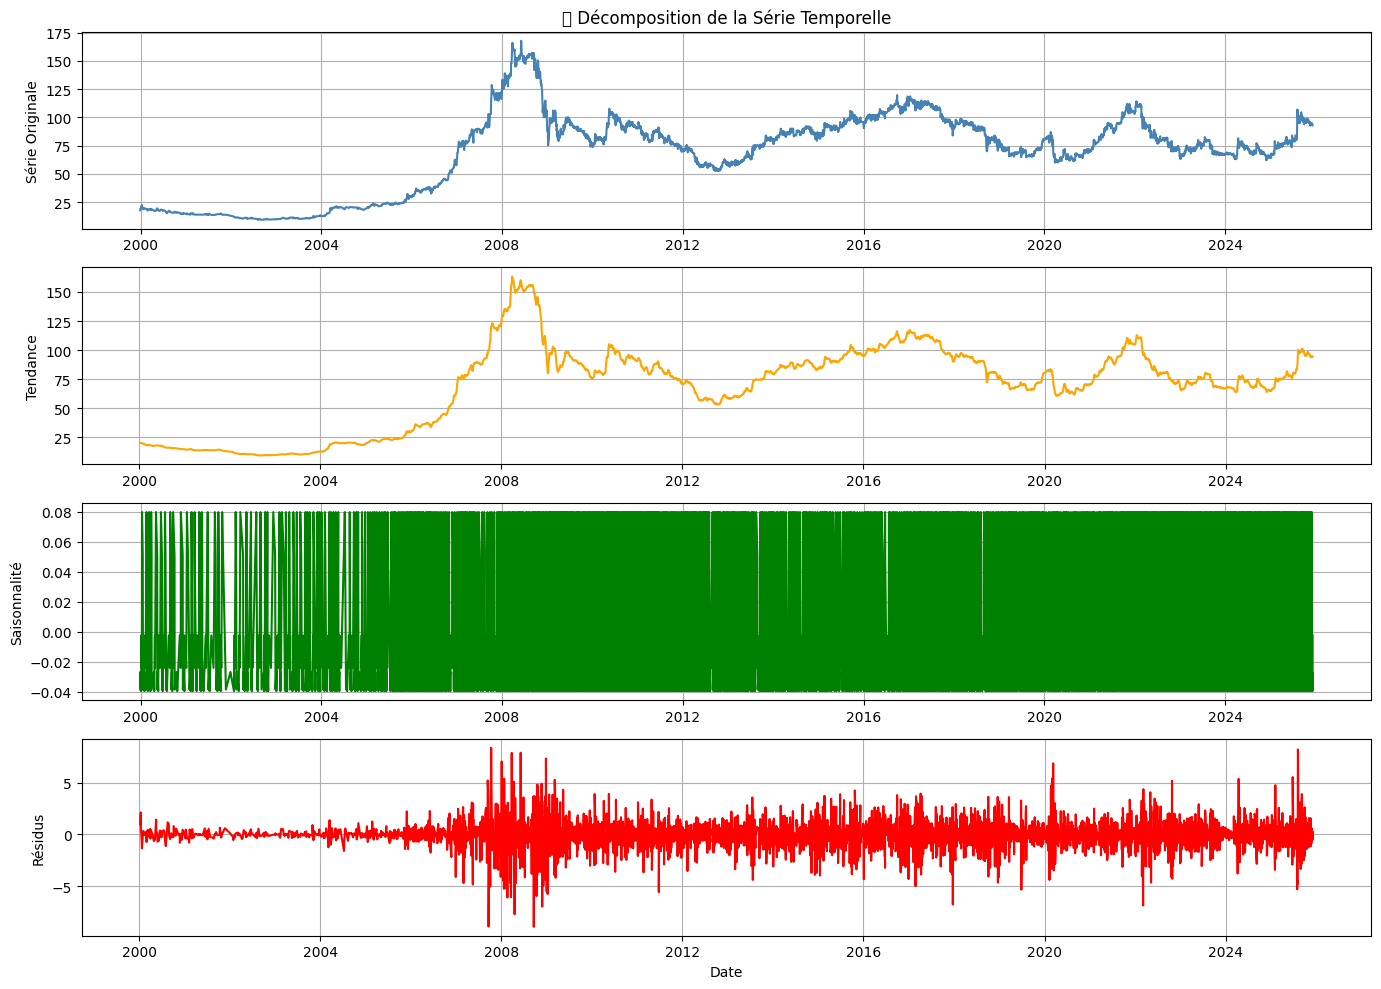

In [11]:
# Visualiser la décomposition
fig, axes = plt.subplots(4, 1, figsize=(14, 10)) 

# 1. Série originale
axes[0].plot(df.index, df['Price'], color='steelblue')
axes[0].set_ylabel('Série Originale')
axes[0].set_title('🔍 Décomposition de la Série Temporelle')
axes[0].grid()

# 2. Tendance
axes[1].plot(df.index, tendance_decompose, color='orange')
axes[1].set_ylabel('Tendance')
axes[1].grid()

# 3. Saisonnalité
axes[2].plot(df.index, saisonnalite_decompose, color='green')
axes[2].set_ylabel('Saisonnalité')
axes[2].grid()

# 4. Résidus
axes[3].plot(df.index, residus, color='red')
axes[3].set_ylabel('Résidus')
axes[3].set_xlabel('Date')
axes[3].grid()

# Ajuster l'espacement entre les graphiques
plt.tight_layout()
plt.show()

### `Moyenne Mobile (Rolling Mean)`

In [12]:
df['MA_30'] = df['Price'].rolling(window=30).mean()  
df['MA_90'] = df['Price'].rolling(window=90).mean()  
df['MA_364'] = df['Price'].rolling(window=364).mean() 

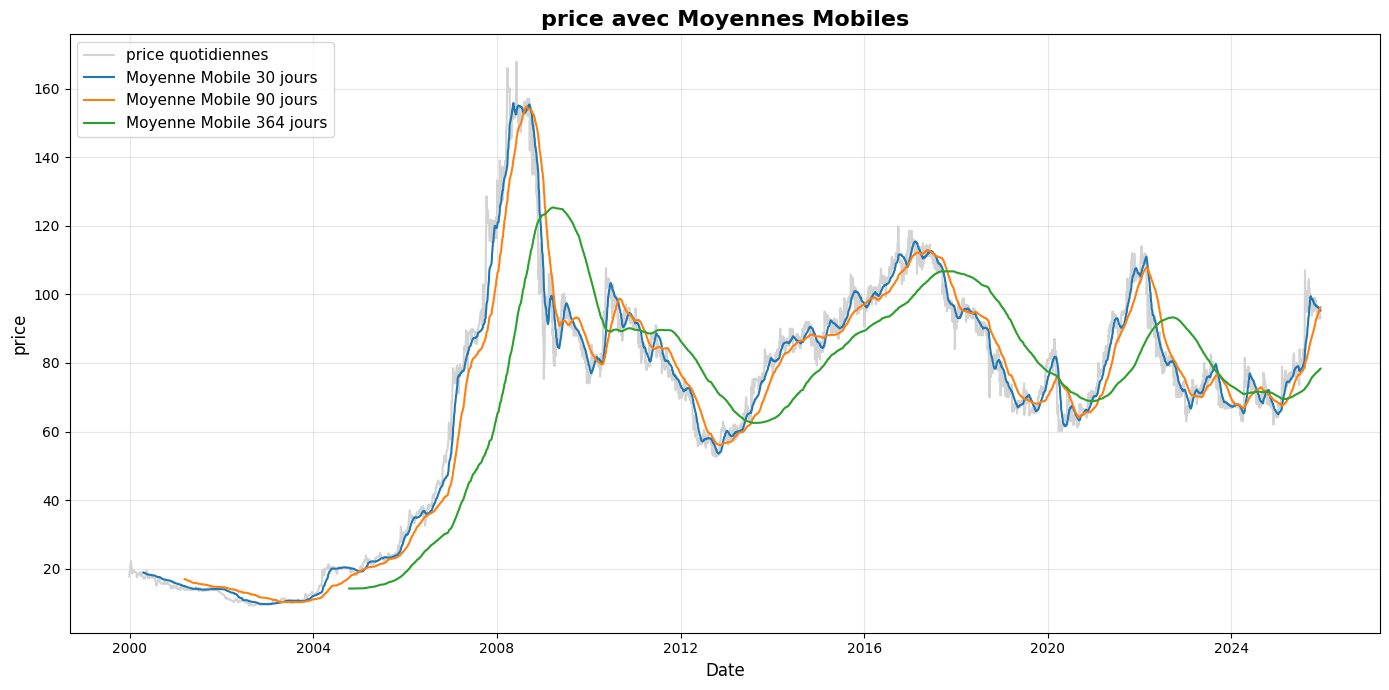

In [13]:
plt.figure(figsize=(14, 7))

# Tracer la série originale
plt.plot(df.index, df['Price'], color='lightgray', label='price quotidiennes')

# Tracer les différentes moyennes mobiles
plt.plot(df.index, df['MA_30'], label='Moyenne Mobile 30 jours')
plt.plot(df.index, df['MA_90'], label='Moyenne Mobile 90 jours')
plt.plot(df.index, df['MA_364'], label='Moyenne Mobile 364 jours')

# Personnalisation
plt.title('price avec Moyennes Mobiles', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('price', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### `Écart-Type Mobile (Rolling Standard Deviation)`

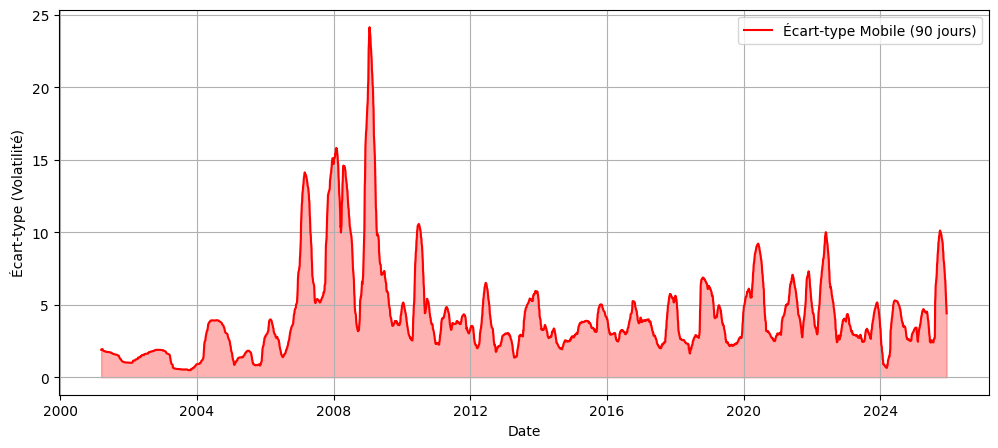

In [14]:
fig, axes = plt.subplots(1, 1, figsize=(12, 5))

df['STD_90'] = df['Price'].rolling(window=90).std()

# Graphique : Écart-type mobile (volatilité)
axes.plot(df.index, df['STD_90'], color='red', label='Écart-type Mobile (90 jours)')
axes.fill_between(df.index, df['STD_90'], alpha=0.3, color='red')
axes.set_ylabel('Écart-type (Volatilité)')
axes.set_xlabel('Date')
axes.legend()
axes.grid()
plt.show()

### `Rééchantillonnage (Resampling)`

In [15]:
# DOWNSAMPLING :
df_mois = df[['Price']].resample('ME').sum() 
df_mois['Price_Moyenne'] = df[['Price']].resample('ME').mean()

print("DONNÉES MENSUELLES (Downsampling)")
print("="*33)
df_mois.head(10)

DONNÉES MENSUELLES (Downsampling)


,Price,Price_Moyenne
Date,,
1999-12-31,36.45,18.225000
2000-01-31,141.94,20.277143
2000-02-29,148.95,18.618750
2000-03-31,221.67,18.472500
2000-04-30,68.87,17.217500
2000-05-31,108.90,18.150000
2000-06-30,124.15,17.735714
2000-07-31,82.75,16.550000
2000-08-31,65.20,16.300000


In [16]:
df_Year = df[['Price']].resample('Y').agg({
    'Price': ['sum', 'mean', 'min', 'max'] 
})

# les noms de colonnes
df_Year.columns = ['price_Total', 'price_Moyenne', 'price_Min', 'price_Max']

print("DONNÉES YEARS")
print("="*13)
df_Year

DONNÉES YEARS


/tmp/ipykernel_17/1832108074.py:1: FutureWarning:

'Y' is deprecated and will be removed in a future version, please use 'YE' instead.



,price_Total,price_Moyenne,price_Min,price_Max
Date,,,,
1999-12-31,36.45,18.225000,17.70,18.75
2000-12-31,1254.46,17.423056,14.25,22.25
2001-12-31,860.61,14.108361,12.93,15.00
2002-12-31,636.04,10.258710,9.25,12.15
2003-12-31,1041.26,10.960632,9.70,13.30
2004-12-31,1796.73,18.715937,12.50,21.20
2005-12-31,3896.25,24.200311,19.50,32.25
2006-12-31,7296.85,39.656793,29.30,62.50
2007-12-31,15881.35,92.333430,64.00,128.65


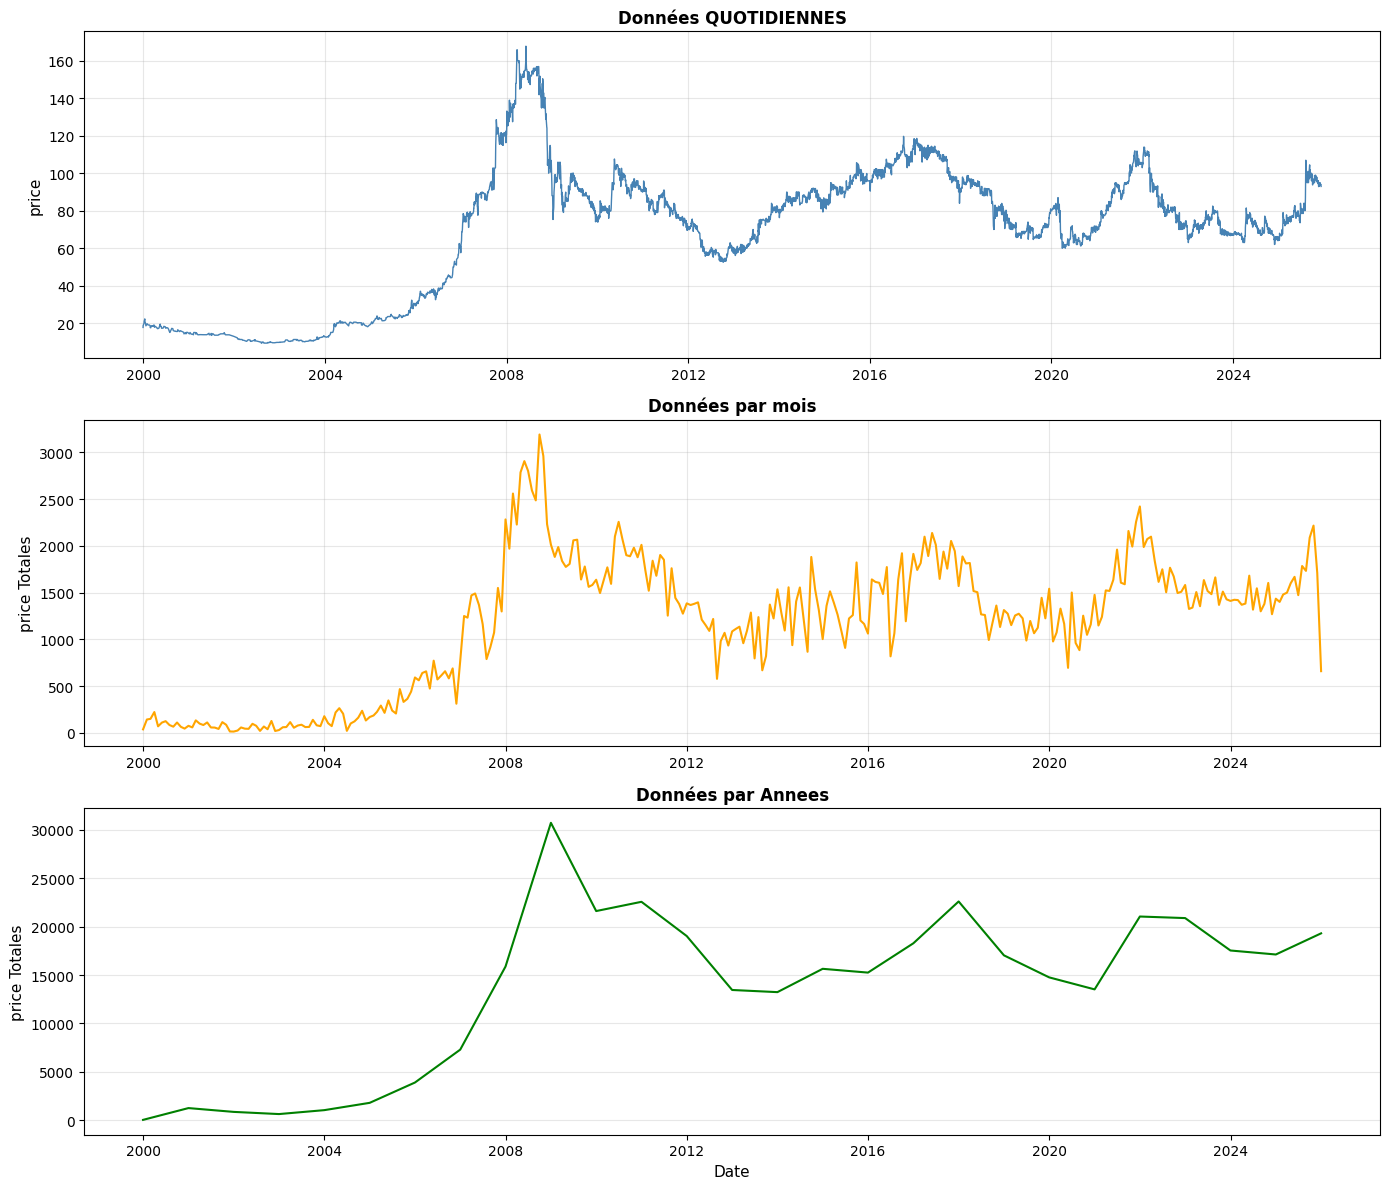

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Données quotidiennes (originales)
axes[0].plot(df.index, df['Price'], color='steelblue', linewidth=1)
axes[0].set_ylabel('price', fontsize=11)
axes[0].set_title('Données QUOTIDIENNES', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 2. Données moisnelles
axes[1].plot(df_mois.index, df_mois['Price'], color='orange')
axes[1].set_ylabel('price Totales', fontsize=11)
axes[1].set_title('Données par mois', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

# 3. Données year
axes[2].plot(df_Year.index, df_Year['price_Total'], color='green')
axes[2].set_ylabel('price Totales', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].set_title('Données par Annees', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## `Détection de Tendance : Test de Stationnarité`

#### `Moyenne et écart-type mobiles`

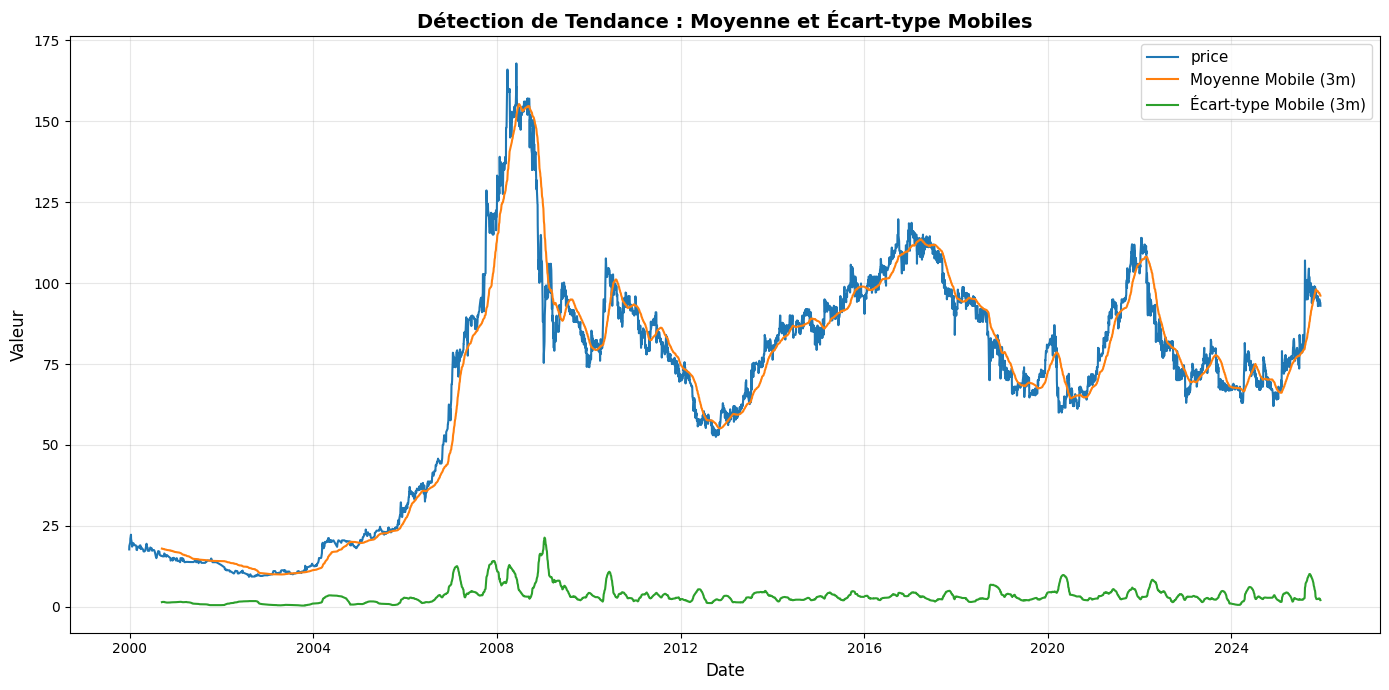

In [18]:
plt.figure(figsize=(14, 7))

# Série originale
plt.plot(df.index, df['Price'], label='price')

# Moyenne et écart-type mobiles
rolling_mean = df['Price'].rolling(window=60).mean()
rolling_std = df['Price'].rolling(window=60).std()
    
plt.plot(df.index, rolling_mean, label='Moyenne Mobile (3m)')
plt.plot(df.index, rolling_std,  label='Écart-type Mobile (3m)')

plt.title('Détection de Tendance : Moyenne et Écart-type Mobiles', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Valeur', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### `Test ADF (Augmented Dickey-Fuller)`

In [19]:
from statsmodels.tsa.stattools import adfuller, kpss

In [20]:
# Test ADF
test_ADF = adfuller(df['Price'].dropna())

# extrair les résultats
adf_statistic = test_ADF[0]
p_value = test_ADF[1]

# Afficher les résultats
print(f"P-value = {p_value:.4f}")
print(adf_statistic)


if p_value < 0.05:
    print(f"La série est STATIONNAIRE (p-value = {p_value:.4f} < 0.05)")
else:
    print(f"La série est NON-STATIONNAIRE (p-value = {p_value:.4f} > 0.05)")

P-value = 0.2524
-2.0805102046816475
La série est NON-STATIONNAIRE (p-value = 0.2524 > 0.05)


#### `Test KPSS (Kwiatkowski-Phillips-Schmidt-Shin)`

In [21]:
# Test KPSS
test_KPSS = kpss(df['Price'].dropna(), regression='c')

# extrair les résultats
kpss_statistic = test_KPSS[0]
p_value = test_KPSS[1]

# Afficher les résultats
print(f"P-value = {p_value:.4f}")
print(kpss_statistic)

if p_value > 0.05:
    print(f"La série est STATIONNAIRE (p-value = {p_value:.4f} > 0.05)")
else:
    print(f"La série est NON-STATIONNAIRE (p-value = {p_value:.4f} < 0.05)")

P-value = 0.0100
1.6763813559393699
La série est NON-STATIONNAIRE (p-value = 0.0100 < 0.05)


/tmp/ipykernel_17/3280006498.py:2: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.




## `Rendre une Série Stationnaire`

#### `Différenciation Simple`

In [22]:
df['price_Diff1'] = df['Price'].diff().dropna() # order 1
df

,Price,MA_30,MA_90,MA_364,STD_90,price_Diff1
Date,,,,,,
1999-12-29,17.70,NaN,NaN,NaN,NaN,NaN
1999-12-30,18.75,NaN,NaN,NaN,NaN,1.05
2000-01-06,19.88,NaN,NaN,NaN,NaN,1.13
2000-01-07,21.00,NaN,NaN,NaN,NaN,1.12
2000-01-12,22.25,NaN,NaN,NaN,NaN,1.25
...,...,...,...,...,...,...
2025-12-03,93.99,95.888000,95.735222,78.087995,5.120576,-0.95
2025-12-04,94.34,95.749333,95.872333,78.149368,4.909524,0.35
2025-12-05,93.99,95.582667,95.983333,78.203242,4.748372,-0.35


In [23]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [24]:
# Créer la figure avec 2 subplots (ligne)
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    subplot_titles=("Série Originale (Non-Stationnaire)",
                                    "Série Différenciée"))

# Série originale
fig.add_trace(go.Scatter(x=df.index, y=df['Price'], 
                         mode='lines', 
                         name='price Originales',
                         line=dict(color='steelblue', width=2)),
              row=1, col=1)

# Série différenciée
fig.add_trace(go.Scatter(x=df.index, y=df['price_Diff1'], 
                         mode='lines', 
                         name='price Différenciées',
                         line=dict(color='green', width=2)),
              row=2, col=1)

# Ajouter une ligne horizontale y=0 pour la série différenciée
fig.add_shape(type="line", x0=df.index.min(), x1=df.index.max(),
              y0=0, y1=0,
              line=dict(color="red", dash="dash"),
              row=2, col=1)

# Mise en page
fig.update_layout(height=700, width=900,
                  showlegend=False,
                  title_text="Visualisation de la Série Originale et Différenciée",
                  template="plotly_white")

fig.update_xaxes(title_text="Date", row=2, col=1)
fig.update_yaxes(title_text="price", row=1, col=1)
fig.update_yaxes(title_text="Différence des price", row=2, col=1)

fig.show()

### `Test de Stationnarité`

In [25]:
# Test ADF
test_ADF = adfuller(df['price_Diff1'].dropna())

# extrair les résultats
adf_statistic = test_ADF[0]
p_value = test_ADF[1]

# Afficher les résultats
print(f"P-value = {p_value:.4f}")
print(adf_statistic)


if p_value < 0.05:
    print(f"La série est STATIONNAIRE (p-value = {p_value:.4f} < 0.05)")
else:
    print(f"La série est NON-STATIONNAIRE (p-value = {p_value:.4f} > 0.05)")

P-value = 0.0000
-45.575840462387106
La série est STATIONNAIRE (p-value = 0.0000 < 0.05)


In [26]:
# Test KPSS
test_KPSS = kpss(df['price_Diff1'].dropna(), regression='c')

# extrair les résultats
kpss_statistic = test_KPSS[0]
p_value = test_KPSS[1]

# Afficher les résultats
print(f"P-value = {p_value:.4f}")
print(kpss_statistic)

if p_value > 0.05:
    print(f"La série est STATIONNAIRE (p-value = {p_value:.4f} > 0.05)")
else:
    print(f"La série est NON-STATIONNAIRE (p-value = {p_value:.4f} < 0.05)")

P-value = 0.1000
0.15400577469521626
La série est STATIONNAIRE (p-value = 0.1000 > 0.05)


/tmp/ipykernel_17/4016523658.py:2: InterpolationWarning:

The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.




## `Autocorrélation : ACF et PACF`

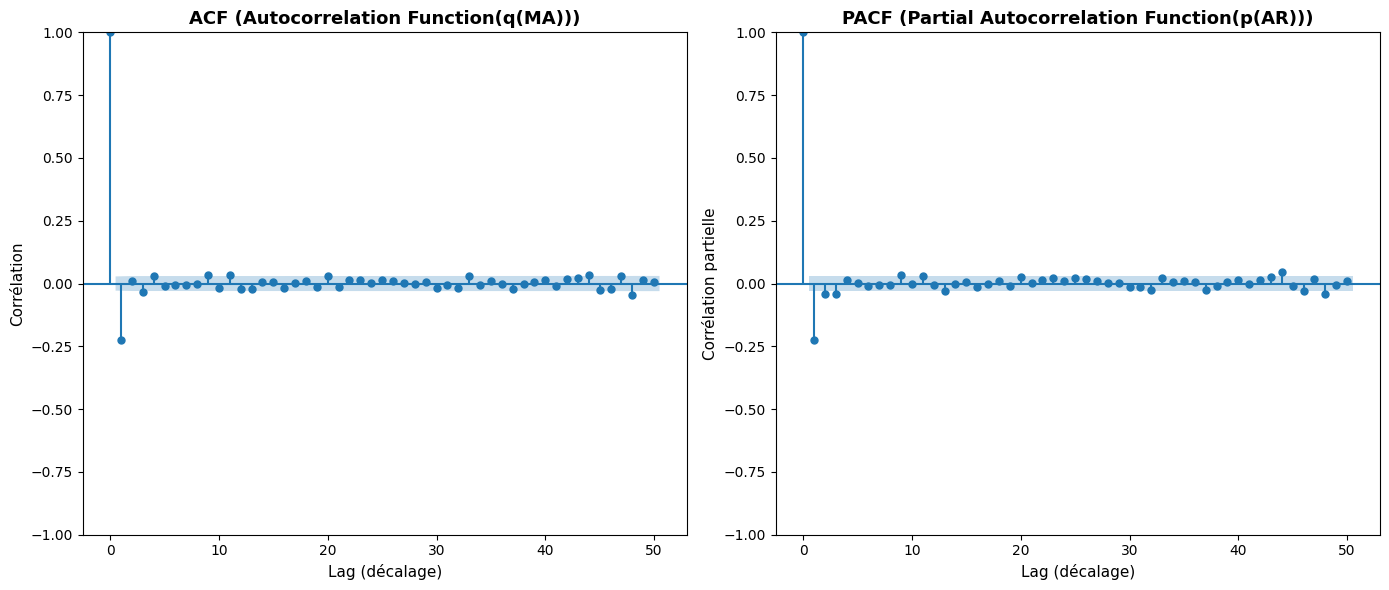

In [27]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df_stationnaire = df['price_Diff1'].dropna() 
serie = pd.Series(df_stationnaire)

# visualisation ACF et PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique ACF
plot_acf(serie, lags=50, ax=axes[0])  
axes[0].set_title('ACF (Autocorrelation Function(q(MA)))', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Lag (décalage)', fontsize=11)
axes[0].set_ylabel('Corrélation', fontsize=11)

# Graphique PACF
plot_pacf(serie, lags=50, ax=axes[1], method='ywm') 
axes[1].set_title('PACF (Partial Autocorrelation Function(p(AR)))', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Lag (décalage)', fontsize=11)
axes[1].set_ylabel('Corrélation partielle', fontsize=11)

plt.tight_layout()
plt.show()

## `modèle`

In [28]:
train_size = int(len(df) * 0.85)
train, test = df['Price'][:train_size], df['Price'][train_size:]

print("Division des données :")
print(f"  - Ensemble d'entraînement : {len(train)} mois ({train.index[0].strftime('%B %Y')} à {train.index[-1].strftime('%B %Y')})")
print(f"  - Ensemble de test : {len(test)} mois ({test.index[0].strftime('%B %Y')} à {test.index[-1].strftime('%B %Y')})")

Division des données :
  - Ensemble d'entraînement : 4061 mois (December 1999 à January 2023)
  - Ensemble de test : 717 mois (January 2023 à December 2025)


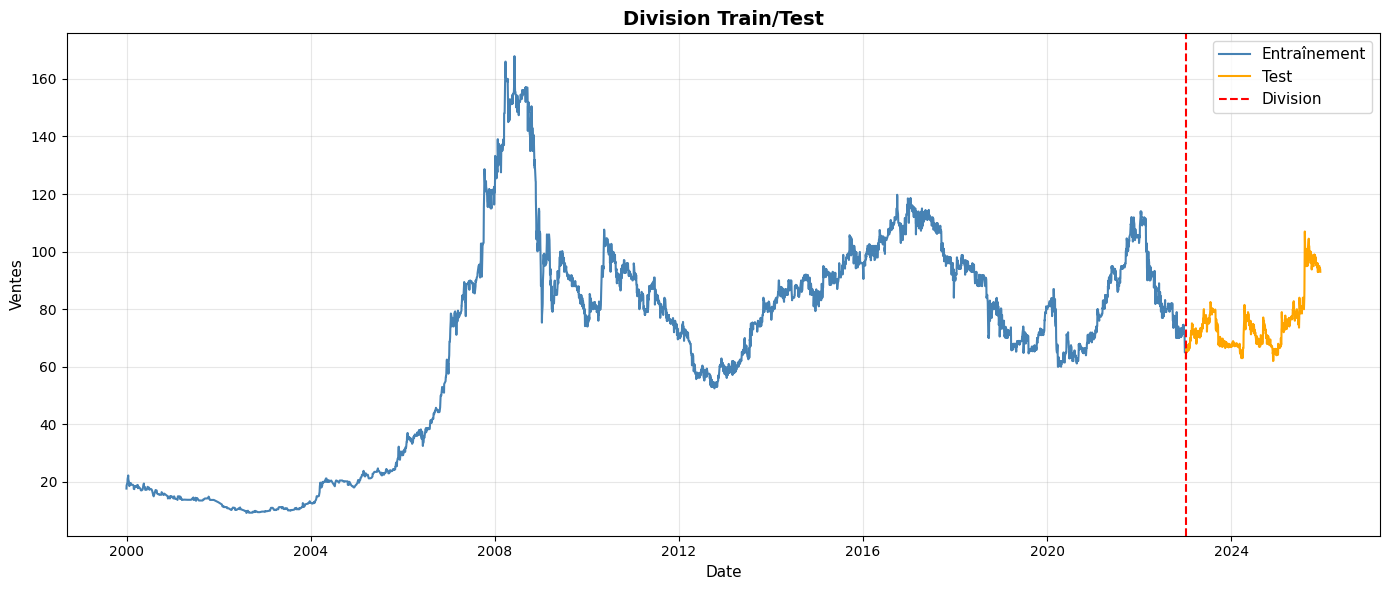

In [29]:
# Visualiser la division
plt.figure(figsize=(14, 6))
plt.plot(train.index, train, label='Entraînement', color='steelblue')
plt.plot(test.index, test, label='Test', color='orange')
plt.axvline(x=train.index[-1], color='red', linestyle='--',  label='Division')
plt.title('Division Train/Test', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=11)
plt.ylabel('Ventes', fontsize=11)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA

### `ARIMA`

In [31]:
# entraîner le modèle ARIMA
model_ARIMA = ARIMA(train, order=(1,1,1)) 
model_ARIMA = model_ARIMA.fit()
print(model_ARIMA.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 4061
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -8178.072
Date:                Wed, 11 Feb 2026   AIC                          16362.144
Time:                        14:33:41   BIC                          16381.071
Sample:                             0   HQIC                         16368.848
                               - 4061                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0314      0.041     -0.766      0.444      -0.112       0.049
ma.L1         -0.2231      0.039     -5.686      0.000      -0.300      -0.146
sigma2         3.2894      0.035     93.905      0.0


--- Validation sur l'ensemble de Test ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



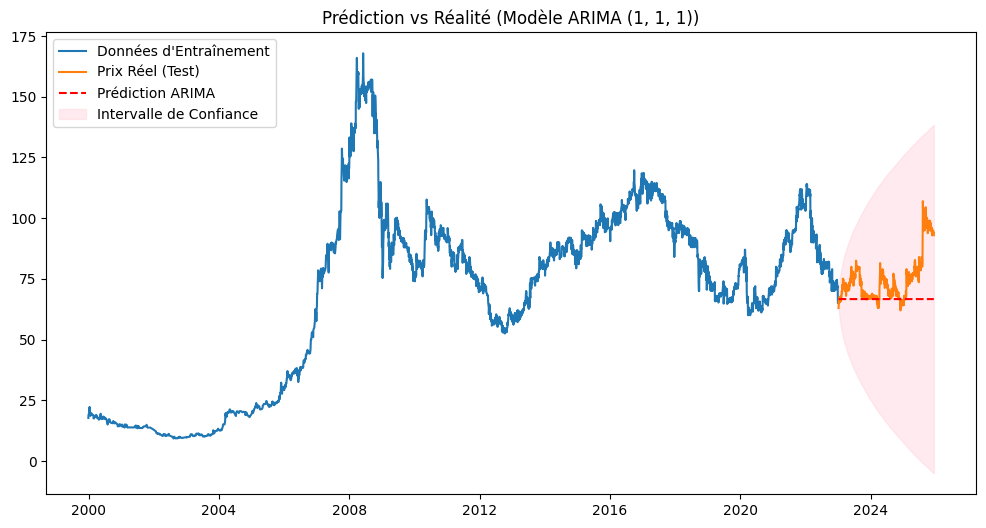

In [32]:
print("\n--- Validation sur l'ensemble de Test ---")

# Forecast sur la période de test
forecast_obj_ARIMA = model_ARIMA.get_forecast(steps=len(test))

# Valeurs prévues
preds_ARIMA = forecast_obj_ARIMA.predicted_mean
preds_ARIMA = pd.Series(preds_ARIMA)
preds_ARIMA.index = test.index

# Intervalles de confiance
conf_int_ARIMA = forecast_obj_ARIMA.conf_int()
conf_int_ARIMA.index = test.index

# Plot
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Données d'Entraînement")
plt.plot(test.index, test, label="Prix Réel (Test)")
plt.plot(preds_ARIMA.index, preds_ARIMA, '--', color='red', label="Prédiction ARIMA")

# Zone de confiance
plt.fill_between(
    test.index,
    conf_int_ARIMA.iloc[:, 0],   # borne inférieure
    conf_int_ARIMA.iloc[:, 1],   # borne supérieure
    color='pink',
    alpha=0.3,
    label="Intervalle de Confiance"
)

plt.title(f"Prédiction vs Réalité (Modèle ARIMA {model_ARIMA.model.order})")  
plt.legend()
plt.show()


In [33]:
# forecast sur la taille de test
forecast_obj_ARIMA = model_ARIMA.forecast(steps=len(test))

# évite l'IndexingError lors de l'utilisation d'un mask booléen
forecast_obj_ARIMA.index = test.index

# Calculer les métriques d'erreur
mape = mean_absolute_percentage_error(test, forecast_obj_ARIMA) * 100
mae = mean_absolute_error(test, forecast_obj_ARIMA)
rmse = np.sqrt(mean_squared_error(test, forecast_obj_ARIMA))

print(f"MAE  (Mean Absolute Error)       : {mae:.2f}")
print(f"RMSE (Root Mean Squared Error)   : {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error)     : {mape:.2f}%")

MAE  (Mean Absolute Error)       : 8.56
RMSE (Root Mean Squared Error)   : 12.50
MAPE (Mean Absolute % Error)     : 10.27%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



### `Modèle SARIMA (Seasonal ARIMA)`

In [34]:
from statsmodels.tsa.statespace.sarimax import SARIMAX 

In [35]:
# Créer et entraîner le modèle SARIMA
model_sarima = SARIMAX(
    train, 
    order=(1, 1, 1),  # (p,d,q)
    seasonal_order=(1, 1, 1, 12),  # (P,D,Q,s)
)

model_sarima_fit = model_sarima.fit() 

# Afficher le résumé
print(model_sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



                                     SARIMAX Results                                      
Dep. Variable:                              Price   No. Observations:                 4061
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -8188.172
Date:                            Wed, 11 Feb 2026   AIC                          16386.343
Time:                                    14:34:04   BIC                          16417.873
Sample:                                         0   HQIC                         16397.513
                                           - 4061                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0339      0.042     -0.817      0.414      -0.115       0.047
ma.L1         -0.2212      0.040   


--- Validation sur l'ensemble de Test ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



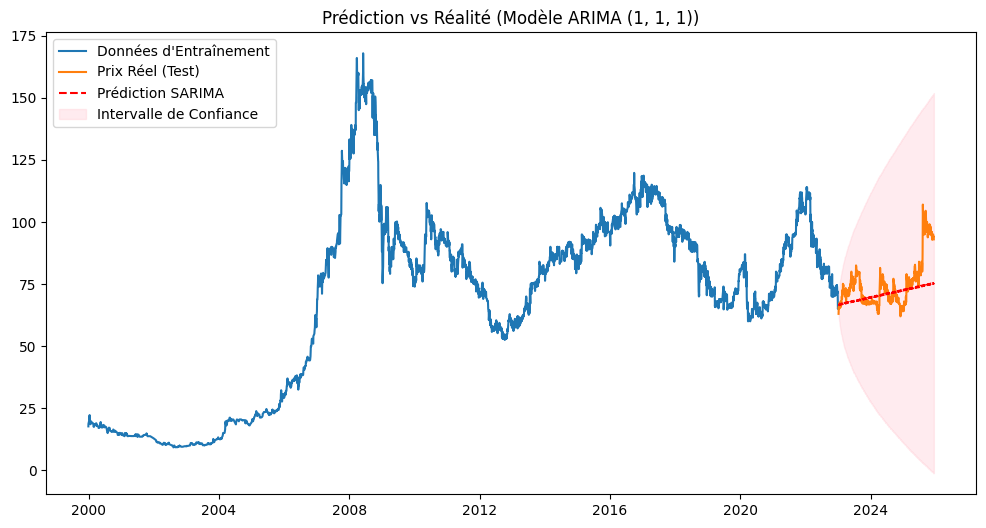

In [36]:
print("\n--- Validation sur l'ensemble de Test ---")

# Forecast sur la période de test
predictions_sarima = model_sarima_fit.get_forecast(steps=len(test))

# Valeurs prévues
preds_SARIMA = predictions_sarima.predicted_mean
preds_SARIMA = pd.Series(preds_SARIMA)
preds_SARIMA.index = test.index

# Intervalles de confiance
conf_int_SARIMA = predictions_sarima.conf_int()
conf_int_SARIMA.index = test.index

# Plot
plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label="Données d'Entraînement")
plt.plot(test.index, test, label="Prix Réel (Test)")
plt.plot(preds_SARIMA.index, preds_SARIMA, '--', color='red', label="Prédiction SARIMA")

# Zone de confiance
plt.fill_between(
    test.index,
    conf_int_SARIMA.iloc[:, 0],   # borne inférieure
    conf_int_SARIMA.iloc[:, 1],   # borne supérieure
    color='pink',
    alpha=0.3,
    label="Intervalle de Confiance"
)

plt.title(f"Prédiction vs Réalité (Modèle ARIMA {model_sarima_fit.model.order})")  
plt.legend()
plt.show()


In [37]:
# forecast sur la taille de test
predictions_sarima = model_sarima_fit.forecast(steps=len(test))

# évite l'IndexingError lors de l'utilisation d'un mask booléen
predictions_sarima.index = test.index

# Calculer les métriques d'erreur
mape_SARIMA = mean_absolute_percentage_error(test, predictions_sarima) * 100
mae_SARIMA = mean_absolute_error(test, predictions_sarima)
rmse_SARIMA = np.sqrt(mean_squared_error(test, predictions_sarima))

print(f"MAE  (Mean Absolute Error)       : {mae_SARIMA:.2f}")
print(f"RMSE (Root Mean Squared Error)   : {rmse_SARIMA:.2f}")
print(f"MAPE (Mean Absolute % Error)     : {mape_SARIMA:.2f}%")

MAE  (Mean Absolute Error)       : 6.37
RMSE (Root Mean Squared Error)   : 9.11
MAPE (Mean Absolute % Error)     : 7.83%


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.



### `Auto ARIMA`

In [38]:
! pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 9.2 MB/s eta 0:00:00


In [39]:
import pmdarima as pm

In [40]:
print("Recherche des meilleurs paramètres p, d, q...")

model = pm.auto_arima(
    train,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,           
    seasonal=True,  
    stepwise=True,
    trace=True,       
    error_action='ignore',
    suppress_warnings=True
)

print(f"\n✅ Meilleur Modèle Trouvé : {model.order}")
print(model.summary())

Recherche des meilleurs paramètres p, d, q...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16614.999, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16372.689, Time=0.22 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16362.076, Time=0.31 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16613.169, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16363.832, Time=0.78 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=16363.857, Time=0.79 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=16364.120, Time=2.09 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=16360.393, Time=0.17 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=16362.144, Time=0.59 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=16362.169, Time=0.27 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=16370.963, Time=0.15 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=16362.430, Time=0.90 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 6.427 seconds

✅ Meilleur Modèle Trouvé : (0

In [41]:
print("\n--- Validation sur l'ensemble de Test ---")

# Prédictions sur la période de test
preds, conf_int = model.predict(n_periods=len(test), return_conf_int=True)
preds = pd.Series(preds)
preds.index = test.index


--- Validation sur l'ensemble de Test ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning:

No supported index is available. Prediction results will be given with an integer index beginning at `start`.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning:

No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.



In [42]:
import plotly.graph_objects as go

# --- 1. Preparation ---
# Extract Lower and Upper bounds from the confidence interval array
lower_bound = conf_int[:, 0]
upper_bound = conf_int[:, 1]

# Create the figure
fig = go.Figure()

# --- 2. Add Traces ---

# A. Training Data (Blue)
fig.add_trace(go.Scatter(
    x=train.index, 
    y=train, 
    mode='lines',
    name="Données d'Entraînement",
    line=dict(color='royalblue')
))

# B. Actual Test Data (Green)
fig.add_trace(go.Scatter(
    x=test.index, 
    y=test, 
    mode='lines',
    name="Prix Réel (Test)",
    line=dict(color='green')
))

# C. Confidence Interval (The Shaded Area)
# 1. Upper Bound (Invisible line)
fig.add_trace(go.Scatter(
    x=preds.index, 
    y=upper_bound,
    mode='lines',
    line=dict(width=0), # Invisible
    showlegend=False,
    name='Upper Bound'
))

# 2. Lower Bound (Fills up to the Upper Bound)
fig.add_trace(go.Scatter(
    x=preds.index, 
    y=lower_bound,
    mode='lines',
    line=dict(width=0), # Invisible
    fill='tonexty', # This fills the area between this trace and the previous one (Upper Bound)
    fillcolor='rgba(255, 182, 193, 0.4)', # Pink with 40% transparency
    name='Intervalle de Confiance (95%)'
))

# D. Prediction (Red Dashed Line)
# We add this LAST so it sits on top of the shaded area
fig.add_trace(go.Scatter(
    x=preds.index, 
    y=preds, 
    mode='lines',
    name="Prédiction ARIMA",
    line=dict(color='red', dash='dash', width=2)
))

# --- 3. Layout Adjustments ---
fig.update_layout(
    title=f"Prédiction ATW vs Réalité (Modèle: {model.order})",
    xaxis_title="Date",
    yaxis_title="Prix (MAD)",
    template="plotly_white",
    hovermode="x unified", # Shows all values for a specific date in one tooltip
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

# Optional: Add a Range Slider to zoom in/out easily
fig.update_xaxes(rangeslider_visible=True)

fig.show()

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

mae = mean_absolute_error(test, preds)
mse = mean_squared_error(test, preds)
rmse = np.sqrt(mse)
mape = np.mean(np.abs(preds - test) / np.abs(test)) * 100

print(f"--- Model Evaluation Metrics ---")
print(f"MAE  (Mean Absolute Error): {mae:.2f} MAD")
print(f"MSE  (Mean Squared Error):  {mse:.2f}")
print(f"RMSE (Root Mean Sq. Error): {rmse:.2f} MAD")
print(f"MAPE (Mean Abs. % Error):   {mape:.2f} %")

--- Model Evaluation Metrics ---
MAE  (Mean Absolute Error): 8.56 MAD
MSE  (Mean Squared Error):  156.16
RMSE (Root Mean Sq. Error): 12.50 MAD
MAPE (Mean Abs. % Error):   10.27 %


# `Diagnostics du Modèle`

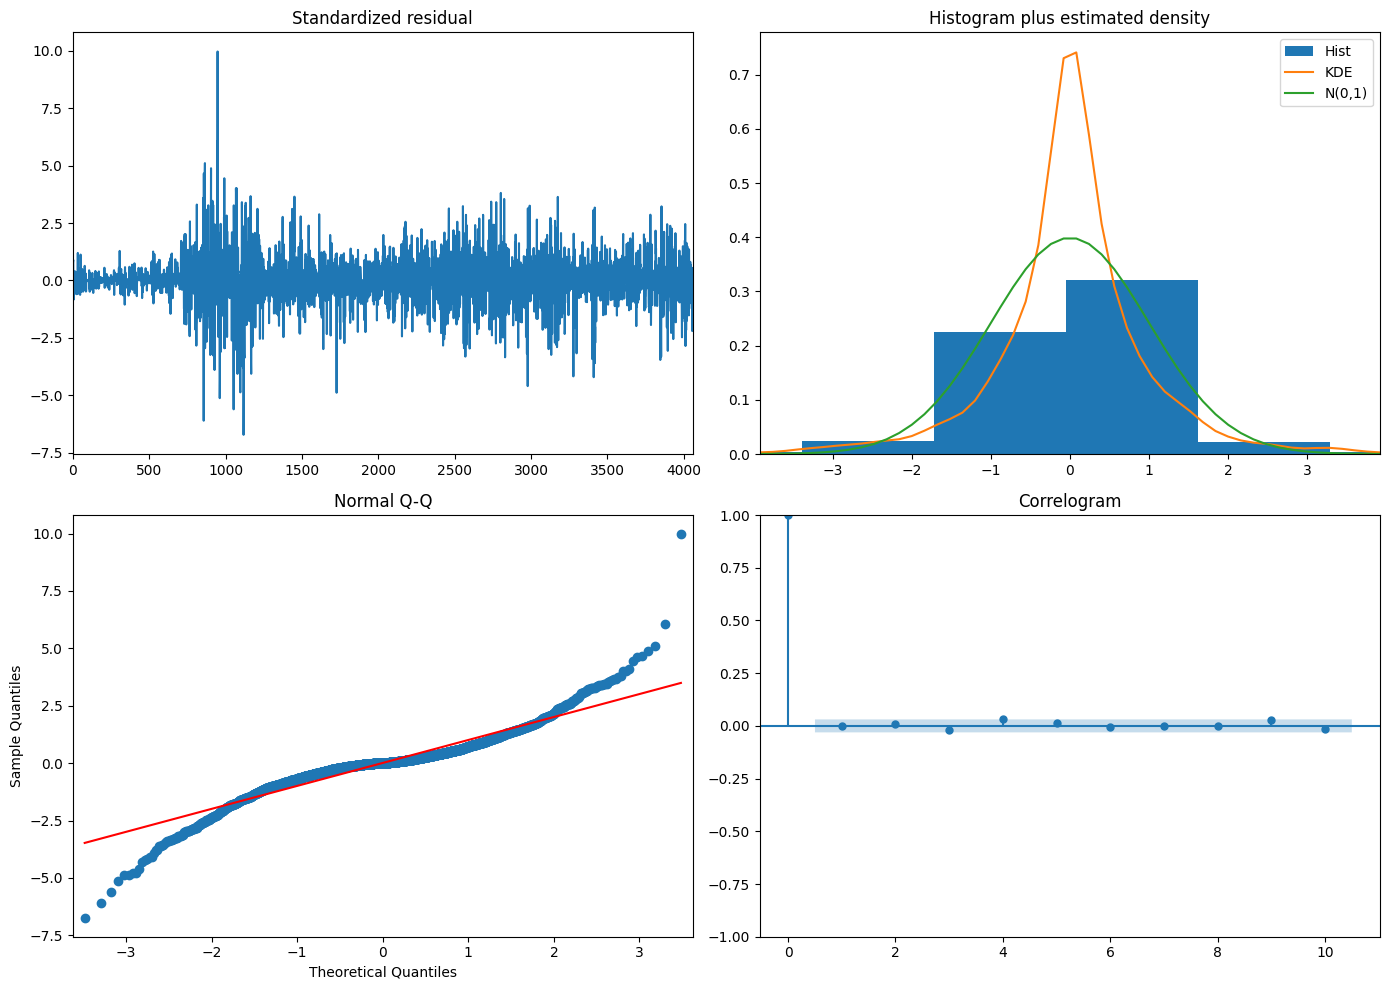

In [44]:
model.plot_diagnostics(figsize=(14, 10))
plt.tight_layout()
plt.show()

# `Prévisions Futures`

In [45]:
df = df.asfreq('B')
df['Price'] = df['Price'].ffill()  # Fill holidays with previous price

print(f"Data loaded: {len(df)} rows ({df.index.min().date()} to {df.index.max().date()})")

Data loaded: 6770 rows (1999-12-29 to 2025-12-09)


In [46]:
# Créer et entraîner le modèle SARIMA
model_sarima = SARIMAX(
    df['Price'], 
    order=(1, 1, 1),  # (p,d,q)
    seasonal_order=(1, 1, 1, 12),  # (P,D,Q,s)
)
model_sarima_fit = model_sarima.fit() 

In [47]:
df["Price"]

Date
1999-12-29    17.70
1999-12-30    18.75
1999-12-31    18.75
2000-01-03    18.75
2000-01-04    18.75
              ...  
2025-12-03    93.99
2025-12-04    94.34
2025-12-05    93.99
2025-12-08    93.98
2025-12-09    93.00
Freq: B, Name: Price, Length: 6770, dtype: float64

# `12 mois`

In [48]:
n_mois_futur = 252

forecast_futur = model_sarima_fit.get_forecast(steps=n_mois_futur)

# valeurs prévues
predictions_futur = forecast_futur.predicted_mean

# intervalles de confiance
intervalle_confiance = forecast_futur.conf_int()

In [49]:
previsions_df = pd.DataFrame({
    'Prévision': predictions_futur,
    'Borne_Inf': intervalle_confiance.iloc[:, 0],
    'Borne_Sup': intervalle_confiance.iloc[:, 1]
})

print("\n📅 PRÉVISIONS POUR LES 12 PROCHAINS MOIS(serie temporelle)")
print("="*70)
print(previsions_df)


📅 PRÉVISIONS POUR LES 12 PROCHAINS MOIS(serie temporelle)
            Prévision  Borne_Inf   Borne_Sup
2025-12-10  93.266721  90.303176   96.230265
2025-12-11  93.330436  89.489014   97.171857
2025-12-12  93.212037  88.741117   97.682958
2025-12-15  93.249015  88.248239   98.249792
2025-12-16  93.322474  87.848651   98.796297
...               ...        ...         ...
2026-11-20  96.025114  60.477568  131.572660
2026-11-23  96.057870  60.436581  131.679159
2026-11-24  96.041764  60.346883  131.736645
2026-11-25  96.037340  60.269018  131.805663
2026-11-26  96.086528  60.244925  131.928131

[252 rows x 3 columns]


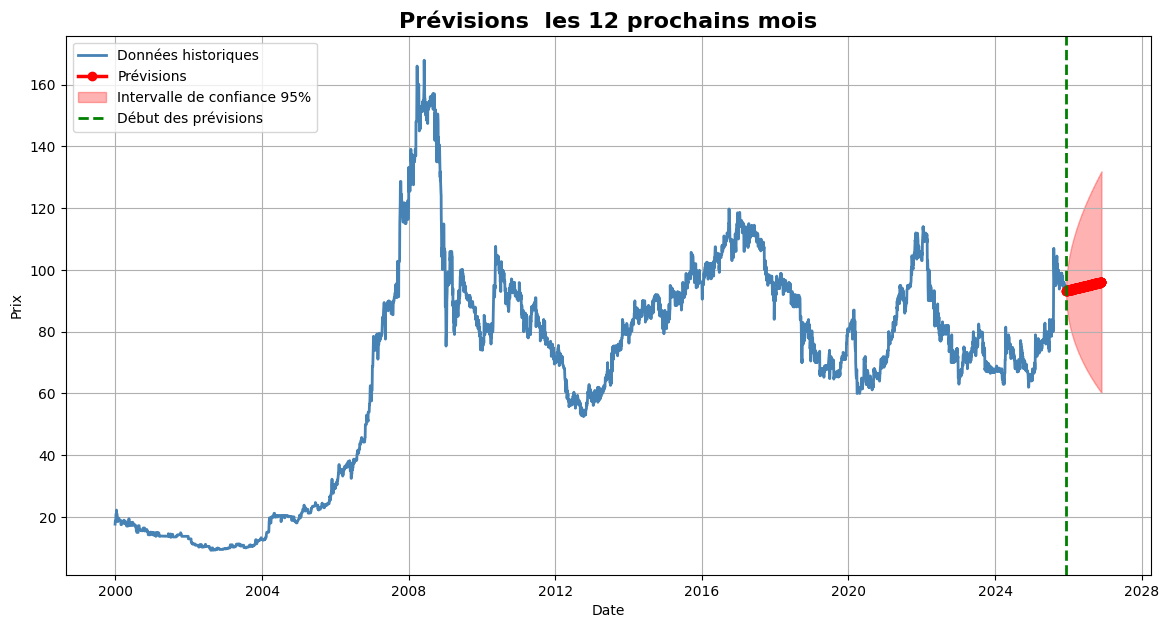

In [50]:
plt.figure(figsize=(14, 7))

plt.plot(df.index, df['Price'], label='Données historiques', color='steelblue', linewidth=2)

plt.plot(previsions_df.index, previsions_df['Prévision'], label='Prévisions', color='red', linewidth=2.5, marker='o')

plt.fill_between(
    previsions_df.index,
    previsions_df['Borne_Inf'],
    previsions_df['Borne_Sup'],
    alpha=0.3, color='red', label='Intervalle de confiance 95%'
)

plt.axvline(x=df.index[-1], color='green', linestyle='--', linewidth=2, label='Début des prévisions')

plt.title('Prévisions  les 12 prochains mois', fontsize=16, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Prix')
plt.legend()
plt.grid(True)
plt.show()

# `améliorer: Machine learning models`

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import plotly.graph_objects as go

In [52]:
df = df.drop(columns=['MA_30', 'MA_90', 'MA_364', 'STD_90', "price_Diff1"])

In [53]:
# Création des 10 Lags (Caractéristiques)
n_lags = 10
df_ml = df[['Price']].copy()
for i in range(1, n_lags + 1):
    df_ml[f'lag_{i}'] = df_ml['Price'].shift(i)

df_ml = df_ml.dropna()
df_ml

,Price,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10
Date,,,,,,,,,,,
2000-01-12,22.25,21.00,21.00,21.00,19.88,18.75,18.75,18.75,18.75,18.75,17.70
2000-01-13,20.91,22.25,21.00,21.00,21.00,19.88,18.75,18.75,18.75,18.75,18.75
2000-01-14,20.91,20.91,22.25,21.00,21.00,21.00,19.88,18.75,18.75,18.75,18.75
2000-01-17,20.91,20.91,20.91,22.25,21.00,21.00,21.00,19.88,18.75,18.75,18.75
2000-01-18,20.91,20.91,20.91,20.91,22.25,21.00,21.00,21.00,19.88,18.75,18.75
...,...,...,...,...,...,...,...,...,...,...,...
2025-12-03,93.99,94.94,95.00,95.00,94.99,94.99,93.90,93.00,94.00,92.95,92.90
2025-12-04,94.34,93.99,94.94,95.00,95.00,94.99,94.99,93.90,93.00,94.00,92.95
2025-12-05,93.99,94.34,93.99,94.94,95.00,95.00,94.99,94.99,93.90,93.00,94.00


In [54]:
# Définition des variables X (Lags) et y (Prix à prédire)
X = df_ml.drop('Price', axis=1)
y = df_ml['Price']

# Train/Test Split : On garde les 30 derniers jours pour le Test
# Note: shuffle=False est OBLIGATOIRE pour les séries temporelles
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=30, shuffle=False)

In [55]:
# Normalisation (Nécessaire pour KNN et SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Taille de l'entraînement : {len(X_train)} jours")
print(f"Taille du test : {len(X_test)} jours")

Taille de l'entraînement : 6730 jours
Taille du test : 30 jours


### ` Entraînement des Modèles `

In [56]:
models = {
    "Régression Linéaire": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=10),
    "SVR": SVR(kernel='rbf', C=10, gamma=0.1),
    "Arbre de Décision": DecisionTreeRegressor(max_depth=12, random_state=42)
}

### `# visualisation des prédictions des modèles vs réalité`

In [57]:
# Dictionnaire pour stocker les erreurs
mae_results = {}

# Création de la figure
fig = go.Figure()

# Tracer le prix réel
fig.add_trace(go.Scatter(
    x=y_test.index,
    y=y_test,
    mode='lines',
    name='Prix Réel',
    line=dict(color='black', width=3)
))

# Boucle sur les modèles
for name, model in models.items():
    
    # Entraînement + prédiction
    if name in ["KNN", "SVR"]:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
    
    # Calcul MAE
    mae = mean_absolute_error(y_test, preds)
    mae_results[name] = mae
    
    # Ajout de la courbe de prédiction
    fig.add_trace(go.Scatter(
        x=y_test.index,
        y=preds,
        mode='lines',
        name=f'{name} (MAE: {mae:.2f})',
        line=dict(dash='dash')
    ))
# Mise en forme
fig.update_layout(
    title="Évaluation des modèles de Régression sur les 30 derniers jours",
    xaxis_title="Date",
    yaxis_title="Prix",
    template="plotly_white",
    hovermode="x unified"
)
# Affichage
fig.show()

### ` Prédiction Future (30 Jours) `

##### ` visualisation interactive avec plotly `

In [58]:
import plotly.graph_objects as go

In [59]:
# Paramètres de prévision
forecast_steps = 30
n_lags = 10

future_dates = pd.date_range(start=df.index[-1], periods=forecast_steps + 1, freq='B')[1:]

# Prix réel (100 derniers jours)
fig = go.Figure()
fig.add_trace(go.Scatter( x=df.index[-100:], y=df['Price'][-100:], mode='lines', name='Prix Réel (Historique)', line=dict(color='black', width=3)))

# Prévisions par modèle
for name, model in models.items():

    current_batch = list(df['Price'].tail(n_lags).values)
    future_preds = []

    for _ in range(forecast_steps):
        input_data = np.array(
            current_batch[-n_lags:][::-1]
        ).reshape(1, -1)

        # Normalisation si nécessaire
        if name in ["KNN", "SVR"]:
            input_data = scaler.transform(input_data)

        pred = model.predict(input_data)[0]
        future_preds.append(pred)
        current_batch.append(pred)

    # Courbe de prévision
    fig.add_trace(go.Scatter(
        x=future_dates,
        y=future_preds,
        mode='lines',
        name=f'Prévision {name}',
        #line=dict(dash='dash'),
        opacity=0.85
    ))

# Ligne verticale "Aujourd'hui"
fig.add_shape(
    type="line",
    x0=df.index[-1],
    x1=df.index[-1],
    y0=0,
    y1=1,
    xref="x",
    yref="paper",
    line=dict(color="red", width=2)
)

fig.add_annotation(
    x=df.index[-1],
    y=1,
    yref="paper",
    text="Aujourd'hui",
    showarrow=False,
    font=dict(color="red", size=12)
)

# Mise en forme globale
fig.update_layout(
    title="Auto Hall : Comparaison Prix Réel vs Prévisions ML (150 Jours)",
    xaxis_title="Date",
    yaxis_title="Prix (MAD)",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        x=0.01,
        y=0.99,
        bgcolor="rgba(255,255,255,0.7)"
    )
)
fig.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid featu

### `best Model`

In [60]:
# ==============================
# Paramètres de prévision
# ==============================
forecast_steps = 30
n_lags = 10

# Dates futures (jours ouvrables)
future_dates = pd.date_range(
    start=df.index[-1],
    periods=forecast_steps + 1,
    freq='B'
)[1:]

# ==============================
# Figure Plotly
# ==============================
fig = go.Figure()

# --- Prix réel (100 derniers jours) ---
fig.add_trace(
    go.Scatter(
        x=df.index[-100:],
        y=df['Price'][-100:],
        mode='lines',
        name='Prix Réel (Historique)',
        line=dict(color='black', width=3)
    )
)

# ==============================
# Prévision KNN uniquement
# ==============================
model = models["KNN"]

current_batch = list(df['Price'].tail(n_lags).values)
future_preds = []

for _ in range(forecast_steps):
    input_data = np.array(
        current_batch[-n_lags:][::-1]
    ).reshape(1, -1)

    # Normalisation (obligatoire pour KNN)
    input_data = scaler.transform(input_data)

    pred = model.predict(input_data)[0]
    future_preds.append(pred)
    current_batch.append(pred)

# --- Courbe de prévision KNN ---
fig.add_trace(
    go.Scatter(
        x=future_dates,
        y=future_preds,
        mode='lines',
        name='Prévision KNN',
        line=dict(width=2),
        opacity=0.9
    )
)

# ==============================
# Ligne verticale "Aujourd'hui"
# ==============================
fig.add_shape(
    type="line",
    x0=df.index[-1],
    x1=df.index[-1],
    y0=0,
    y1=1,
    xref="x",
    yref="paper",
    line=dict(color="red", width=2)
)

fig.add_annotation(
    x=df.index[-1],
    y=1,
    yref="paper",
    text="Aujourd'hui",
    showarrow=False,
    font=dict(color="red", size=12)
)

# ==============================
# Mise en forme globale
# ==============================
fig.update_layout(
    title="Auto Hall : Prix Réel vs Prévision KNN (30 Jours)",
    xaxis_title="Date",
    yaxis_title="Prix (MAD)",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        x=0.01,
        y=0.99,
        bgcolor="rgba(255,255,255,0.7)"
    )
)

fig.show()


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but StandardScaler was fitted with feature names

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, 

### `les metriques `

In [61]:
# Dictionnaire pour stocker les scores
performance_metrics = []

for name, model in models.items():
    # Prédictions sur l'ensemble de TEST
    if name in ["KNN", "SVR"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)
    
    # Calcul des métriques
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    performance_metrics.append({
        'Modèle': name,
        'MAE (MAD)': round(mae, 2),
        'RMSE (MAD)': round(rmse, 2),
        'R² Score': round(r2, 3)
    })

# Création d'un DataFrame pour un affichage propre
metrics_df = pd.DataFrame(performance_metrics).set_index('Modèle')
metrics_df = metrics_df.sort_values(by='MAE (MAD)')

print("--- TABLEAU COMPARATIF DES PERFORMANCES ---")
print("="*43)
display(metrics_df)

--- TABLEAU COMPARATIF DES PERFORMANCES ---


,MAE (MAD),RMSE (MAD),R² Score
Modèle,,,
SVR,0.75,1.05,0.405
Régression Linéaire,0.77,1.04,0.418
KNN,0.83,1.05,0.404
Arbre de Décision,0.93,1.18,0.253


### `Visualisation les metriques`

In [62]:
import plotly.graph_objects as go
import pandas as pd

# --- Données ---
data = {
    'Modèle': ['SVR', 'Régression Linéaire', 'KNN', 'Arbre de Décision'],
    'MAE': [0.74, 0.77, 0.83, 0.93],
    'RMSE': [1.05, 1.04, 1.05, 1.18],
    'R2': [0.405, 0.418, 0.404, 0.253]
}

df_perf = pd.DataFrame(data)

# --- Création de la figure ---
fig = go.Figure()

# MAE
fig.add_trace(go.Bar(
    x=df_perf['Modèle'],
    y=df_perf['MAE'],
    name='MAE (MAD)',
    marker_color='orange'
))

# RMSE
fig.add_trace(go.Bar(
    x=df_perf['Modèle'],
    y=df_perf['RMSE'],
    name='RMSE (MAD)',
    marker_color='blue'
))

# R²
fig.add_trace(go.Bar(
    x=df_perf['Modèle'],
    y=df_perf['R2'],
    name='R² Score',
    marker_color='green'
))

# --- Mise en forme ---
fig.update_layout(
    title='Comparaison des performances des modèles',
    xaxis_title='Modèle',
    yaxis_title='Valeur',
    barmode='group',
    template='plotly_white',
    hovermode='x unified'
)

# Affichage
fig.show()

------------------------------
-----------------------------
-------------------------

----------

## ***`Model DL ( LSTM )`***

- **LSTM (Long Short-Term Memory):**

- **C’est un type de réseau de neurones récurrent (RNN) spécialement conçu pour apprendre les dépendances à long terme dans les séries temporelles ou séquences.**

***But principal :*** **mémoriser des informations importantes sur de longues périodes et oublier les données non pertinentes.**

**Utilisation courante : prévisions financières, météo, ventes...**

- ***`2️⃣ Normalisation (OBLIGATOIRE pour LSTM)`***

In [63]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))


- ***`3️⃣ Création des séquences temporelles (clé du LSTM)`***

In [64]:
import numpy as np

def create_sequences(X, y, n_steps):
    X_seq, y_seq = [], []
    for i in range(n_steps, len(X)):
        X_seq.append(X[i-n_steps:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

# Nombre de pas de temps (lags)
n_steps = 10

X_seq, y_seq = create_sequences(X_scaled, y_scaled, n_steps)


- ***`4️⃣ Train / Test Split temporel (30 derniers jours)`***

In [65]:
X_train = X_seq[:-30]
X_test  = X_seq[-30:]

y_train = y_seq[:-30]
y_test  = y_seq[-30:]


- ***`5️⃣ Construction du modèle LSTM 🧠`***

In [66]:
# %pip install -q tensorflow

In [67]:
# Install TensorFlow in the notebook environment (required if not already installed)
# %pip install -q tensorflow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(32, return_sequences=True, input_shape=(n_steps, X_train.shape[2])),
    Dropout(0.2),

    LSTM(16),
    Dropout(0.2),

    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse'
)

model.summary()


2026-02-11 14:35:11.026412: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770820511.293691      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770820511.370909      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770820512.030465      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770820512.030516      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770820512.030519      17 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 10, 32)         │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,657 (33.82 KB)

 Trainable params: 8,657 (33.82 KB)

 Non-trainable params: 0 (0.00 B)

In [68]:
from tensorflow.keras.callbacks import EarlyStopping

es = EarlyStopping(monitor ='val_loss', patience = 25,
                    restore_best_weights = True)


In [69]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau( 
     monitor='val_loss',
     factor=0.5,       # divise le learning rate par 2
     patience=5,
     min_lr=1e-6
)


- ***`6️⃣ Entraînement du modèle`***

In [70]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=64, 
    validation_split=0.1,
    verbose=1 , 
    callbacks=[es , reduce_lr] 
)


Epoch 1/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0638 - val_loss: 4.4253e-04 - learning_rate: 0.0010
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0046 - val_loss: 7.6290e-04 - learning_rate: 0.0010
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0044 - val_loss: 5.3819e-04 - learning_rate: 0.0010
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0039 - val_loss: 4.8800e-04 - learning_rate: 0.0010
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0036 - val_loss: 3.9950e-04 - learning_rate: 0.0010
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0033 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 7/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0033 - val_loss: 4.6094e-04 - learning_rate: 5.0000e-04
Epoch 8/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0031 - val_loss: 4.1739e-04 - learning_rate: 5.0000e-04
Epoch 9/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0029 - val_loss: 4.171

- ***`7️⃣ Prédiction + remise à l’échelle`***

In [71]:
y_pred_scaled = model.predict(X_test)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_real = scaler_y.inverse_transform(y_test)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step


- ***`8️⃣ Évaluation des performances 📊`***

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test_real, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_real, y_pred))
r2 = r2_score(y_test_real, y_pred)

print(f"MAE  : {mae:.3f}") 
print(f"RMSE : {rmse:.3f}")
print(f"R²   : {r2:.3f}") 


MAE  : 1.584
RMSE : 1.994
R²   : -1.136


- ***`9️⃣ Visualisation (réel vs LSTM)`***

In [73]:
import plotly.graph_objects as go

# Création de la figure
fig = go.Figure()

# Courbe prix réel
fig.add_trace(
    go.Scatter(
        y=y_test_real.flatten(),
        mode='lines',
        name='Prix Réel',
        line=dict(width=3, color='black')
    )
)

# Courbe prévision LSTM
fig.add_trace(
    go.Scatter(
        y=y_pred.flatten(),
        mode='lines',
        name='Prévision LSTM',
        line=dict(dash='dash', width=2)
    )
)

# Mise en forme
fig.update_layout(
    title="Prix Réel vs Prévision LSTM",
    xaxis_title="Périodes (Test)",
    yaxis_title="Prix",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        x=0.01,
        y=0.99,
        bgcolor="rgba(255,255,255,0.7)"
    )
)

fig.show()


------------

## ***`Forcasting`***

In [74]:
forecast_steps = 30

future_dates = pd.date_range(
    start=df.index[-1],
    periods=forecast_steps + 1,
    freq='B'   # jours ouvrables
)[1:]


In [75]:
# Dernière séquence connue
last_sequence = X_seq[-1].copy()

future_preds_scaled = []

for _ in range(forecast_steps):
    # Prédiction
    pred = model.predict(last_sequence.reshape(1, n_steps, X_train.shape[2]), verbose=0)
    future_preds_scaled.append(pred[0, 0])

    # Mise à jour de la séquence
    last_sequence = np.roll(last_sequence, -1, axis=0)
    last_sequence[-1, 0] = pred  # si Price est la 1ère feature


/tmp/ipykernel_17/3073838515.py:13: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



In [76]:
import plotly.graph_objects as go

fig = go.Figure()

# --- Historique ---
fig.add_trace(
    go.Scatter(
        x=df.index[-120:],
        y=df['Price'][-120:],
        mode='lines',
        name='Prix Réel (Historique)',
        line=dict(color='black', width=3)
    )
)

# --- Test LSTM ---
fig.add_trace(
    go.Scatter(
        x=df.index[-30:],
        y=y_pred.flatten(),
        mode='lines',
        name='Prévision LSTM (Test)',
        line=dict(dash='dash', width=2)
    )
)

# --- Forecast 30 jours ---
fig.add_trace(
    go.Scatter(
        x=future_dates,
        y=future_preds,
        mode='lines',
        name='Forecast LSTM (30 jours)',
        line=dict(color='blue', width=2)
    )
)

# --- Ligne "Aujourd’hui" ---
fig.add_shape(
    type="line",
    x0=df.index[-1],
    x1=df.index[-1],
    y0=0,
    y1=1,
    xref="x",
    yref="paper",
    line=dict(color="red", width=2)
)

fig.add_annotation(
    x=df.index[-1],
    y=1,
    yref="paper",
    text="Aujourd'hui",
    showarrow=False,
    font=dict(color="red", size=12)
)

# --- Mise en forme ---
fig.update_layout(
    title="Prix Réel vs Prévision & Forecast LSTM (30 Jours)",
    xaxis_title="Date",
    yaxis_title="Prix",
    template="plotly_white",
    hovermode="x unified",
    legend=dict(
        x=0.01,
        y=0.99,
        bgcolor="rgba(255,255,255,0.7)"
    )
)

fig.show()


--------------
-----------
------------

# ***``Reseme Global``***

- ### ***`Résumé des métriques globales`***

| Modèle                   | MAE   | RMSE  | R²    |
| ------------------------ | ----- | ----- | ----- |
| SVR (ML)                 | 0.75  | 1.05  | 0.405 |
| Régression Linéaire (ML) | 0.77  | 1.04  | 0.418 |
| KNN (ML)                 | 0.83  | 1.05  | 0.404 |
| Arbre de Décision (ML)   | 0.93  | 1.18  | 0.253 |
| LSTM (DL)                | 1.103 | 1.294 | 0.100 |


- ### ***`Table de Comparatif Entre les Prevesion et Reel`***

| Date       | Modèle     | Prévision | Prix Réel | Erreur (Prévision - Réel) | Observations                  |
|------------|------------|-----------|-----------|---------------------------|-------------------------------|
| 29/12/2025 | KNN (ML)   | 92.9      | 93.2      | 0.3                       | Très proche du réel           |
| 29/12/2025 | LSTM (DL)  | 92.9      | 93.2      | 0.3                       | Très proche du réel           |
| 30/12/2025 | KNN (ML)   | 92.8      | 95.9      | 3.1                       | Sous-estimation notable       |
| 30/12/2025 | LSTM (DL)  | 92.8      | 95.9      | 3.1                       | Sous-estimation notable       |
